---

**Exercise 1 : Use the openpyxl module to create a new workbook and add values/formulae to it**

---


In [7]:
from openpyxl import Workbook

wb = Workbook()
ws = wb.active

ws['A1'] = "First number ==> "
ws['B1'] = 2

ws['A2'] = "Second number ==> "
ws['B2'] = 8

ws['B3'] = "=B1*B2"

wb.save('simple_calculator.xlsx')

---

**Exercise 2 : Open an Excel workbook and read down a list of plants finding the ones not in stock**

---


In [ ]:
import openpyxl
import warnings
warnings.filterwarnings("ignore")

# Open the Excel workbook
wb = openpyxl.load_workbook('/content/Plants.xlsx')
ws = wb['Sheet1']  # Change the sheet name if different

row = 2  # Start from the second row (cell A2)
while True:
    plant_cell = ws.cell(row=row, column=1)  # Column A is 1
    plant_name = plant_cell.value

    if plant_name is None:
        break  # Stop when reaching an empty cell

    in_stock_cell = ws.cell(row=row, column=8)  # Column H is 8
    in_stock_value = in_stock_cell.value

    # If the plant is not in stock, print its name
    if str(in_stock_value).strip().lower() == "no":
        print(plant_name)

    row += 1  # Move to the next row

---

**Exercise 3 : Load Excel File and Write the Data**

---


In [3]:
import pandas as pd
from openpyxl import load_workbook

# Load the Excel file
file_path = '/content/data.xlsx'
df = pd.read_excel(file_path)

# Filter
filtered_df = df[df['Sales'] > 1000]

wb = load_workbook(file_path)
ws = wb.active


ws.delete_rows(2, ws.max_row)

for idx, row in filtered_df.iterrows():
    ws.append(list(row))

# Save
wb.save('data_new.xlsx')

---

**Exercise 4 : Load Excel File, plot charts and Manipulate Data**

---


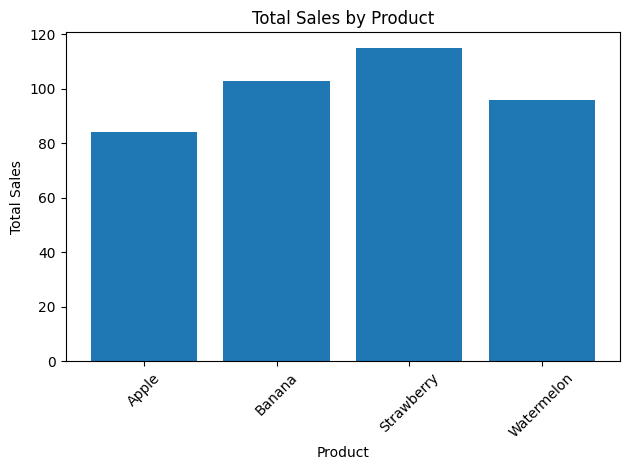

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Read data
df = pd.read_excel('/content/productSales.xlsx')

# Group by product and sum sales
grouped_df = df.groupby('product')['sales'].sum().reset_index()

# Export grouped data to a new Excel file
output_path = '/content/sales_report.xlsx'
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    grouped_df.to_excel(writer, index=False)
# Не надо writer.save()!

# Plot a bar chart of product sales
plt.bar(grouped_df['product'], grouped_df['sales'])
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.title('Total Sales by Product')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()